# Create/Copy All Files Needed to Run the Calibration Simulation in the Calibration Path and Create the Commands File and Submit Jobs File

In [1]:
from collections import defaultdict
from matplotlib.colors import LogNorm
from pathlib import Path
import jenkspy
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import shutil
import string

from _configs.country_config import *
from _configs.files_config import *
from _configs.run_config import *

from _utils.utils import *

In [2]:
# check if calibration path exists and throw exception if it does, advise user to increase run number
if os.path.exists(calibration_path):
    print(f"Calibration path {calibration_path} already exists.")
    raise Exception(f"Calibration path {calibration_path} already exists.\nIncrease the run number in the config file to avoid overwriting previous results.")

Model Population vs Observed Population in Calibration Year should be within ~500k - Kien

We do not need to generate all combinations of treatment access and bins, just combinations that are present in the real raster data

In [3]:
''' This is using the actual betas and access rates from the country_config.py file, not the pop_calibration_config dictionary. '''
assert len(betas) >= 3, f"Need at least 3 betas, got {len(betas)}"
print(f"Using {len(betas)} betas for calibration.")
# treatment_access_rates = [0.451, 0.486, 0.561, 0.603, 0.661, 0.676, 0.755, 0.783, 0.787, 0.847]

Using 19 betas for calibration.


## Use jenkpy for population_bins

In [4]:
projected_population_raster, metadata = read_raster(initial_population_projected_raster_path)
district_raster, metadata  = read_raster(districts_raster_path)
treatment_raster, metadata  = read_raster(treatment_seeking_raster_path)

NODATA = metadata["NODATA_value"]
mask = district_raster != NODATA

print(metadata)

district_mapping = pd.read_csv(f"{data_path}/{country_code}_mapping.csv")
district_mapping.columns = ['district_id', 'district_name']
# district_mapping.columns = ['district_name', 'district_id']

if district_mapping['district_id'].dtype != int:
    raise Exception(f"district_id column in is not of type int. Please check if district mapping columns (['district_name', 'district_id']) are flipped")


{'ncols': 277, 'nrows': 308, 'xllcorner': -540299.14387948, 'yllcorner': 7980296.7276279, 'cellsize': 5000.0, 'NODATA_value': -9999}


In [5]:
district_mapping

,district_id,district_name
0,1,Bengo
1,2,Bie
2,3,Cabinda
3,4,Cuando cubango
4,5,Cuanza Norte
5,6,Cuanza Sul
6,7,Cunene
7,8,Huambo
8,9,Hulia
9,10,Luanda


In [6]:
min(treatment_raster[treatment_raster > 0]) , max(treatment_raster[treatment_raster > 0])

(np.float64(0.02755906), np.float64(1.0))

In [7]:
total_projected_pop_calibration_year = np.nansum(projected_population_raster[mask])
print(f"Total population: \n{total_projected_pop_calibration_year:,.0f}")

Total population: 
33,486,433


In [8]:
max_pop_value = np.max(projected_population_raster[projected_population_raster != NODATA])
print(f"Max pixel value in population raster: {max_pop_value:,.3f}")

Max pixel value in population raster: 1,236,410.000


District Raster (valid values):
[3. 3. 3. ... 4. 4. 4.]
Shape: (308, 277)

Treatment Access Raster (valid values):
[1.        1.        1.        ... 0.8031496 0.8031496 0.8031496]
Shape: (308, 277)

Projected Population Raster (valid values):
[167.  34. 559. ...  85.  15.   5.]


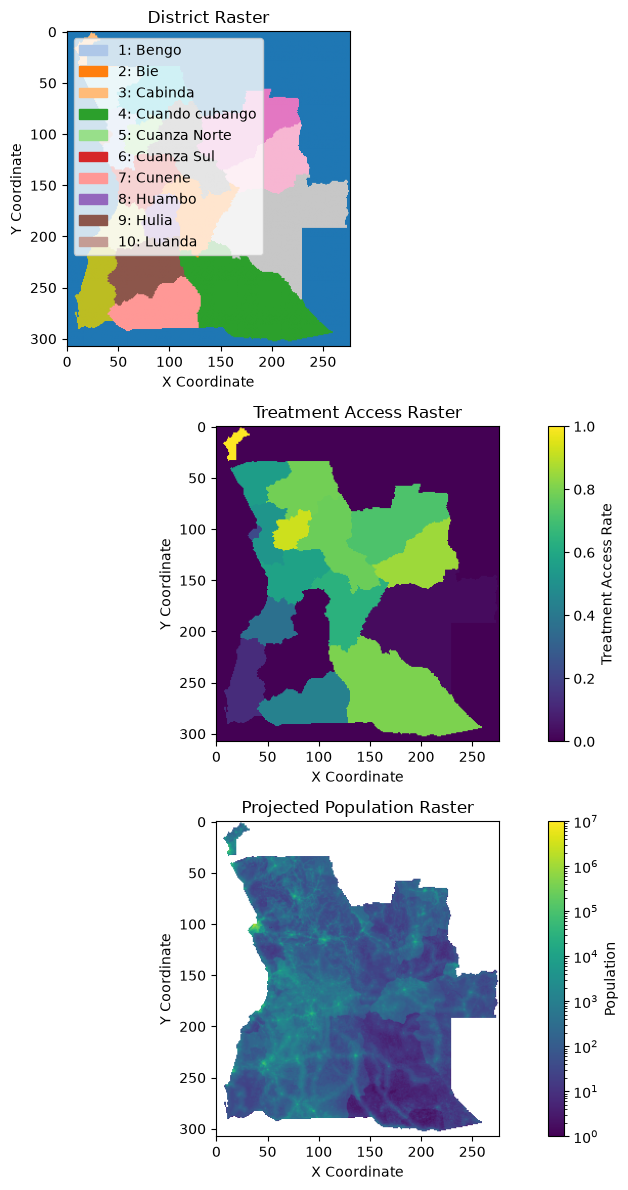

In [9]:
# plot raster data with districts colored by district id and overlay treatment raster as a heatmap
# using 'tab20' colormap for districts and 'Reds' colormap for treatment access rate
# in 3x1 plot with shared x and y axes, and colorbar for treatment access rate on the right
plt.figure(figsize=(10,12))

# District raster
plt.subplot(3, 1, 1)
district_cmap = plt.get_cmap('tab20', np.max(district_raster.astype(int)) + 1)
plt.imshow(district_raster, cmap=district_cmap, vmin=0, vmax=np.max(district_raster))
# plt.colorbar(ticks=np.arange(0, np.max(district_raster.astype(int)) + 1), label='District ID')
unique_ids = np.unique(district_raster[district_raster != NODATA]).astype(int)
legend_ids = unique_ids[:10]  # show up to 10 districts for a simple legend
patches = []
for i in legend_ids:
    name_row = district_mapping[district_mapping['district_id'] == i]
    label = f"{i}: {name_row['district_name'].values[0]}" if not name_row.empty else str(i)
    patches.append(mpatches.Patch(color=district_cmap(i), label=label))
plt.legend(handles=patches, loc='upper left')
plt.title('District Raster')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')

# Treatment access raster
plt.subplot(3, 1, 2)
treatment_cmap = plt.get_cmap('viridis')   
plt.imshow(treatment_raster, cmap=treatment_cmap, vmin=0, vmax=1)
plt.colorbar(label='Treatment Access Rate')
plt.title('Treatment Access Raster')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')

# Population raster
plt.subplot(3, 1, 3)
population_cmap = plt.get_cmap('viridis') 
plt.imshow(projected_population_raster, cmap=population_cmap, norm=LogNorm(vmin=1, vmax=1e7))
# plt.imshow(population_raster, cmap=population_cmap)
plt.colorbar(label='Population')
plt.title('Projected Population Raster')    
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.tight_layout()


# print the three rasters as arrays of valid values (not including NODATA) and their shapes
print("District Raster (valid values):")
print(district_raster[mask])
print(f"Shape: {district_raster.shape}")
print("\nTreatment Access Raster (valid values):")
print(treatment_raster[mask])
print(f"Shape: {treatment_raster.shape}")   
print("\nProjected Population Raster (valid values):")
print(projected_population_raster[mask])

In [10]:
# Initialize mapping from health district to population and treatment values
district_population_and_treatement_dict = defaultdict(lambda: {'population_bin': [], 'treatment': []})

# Flatten the grids for easy iteration
district_flat = district_raster.flatten()
population_flat = projected_population_raster.flatten()
treatment_flat = treatment_raster.flatten()

NODATA = metadata['NODATA_value']

# Iterate over the flattened arrays
for district_id, pop, treat in zip(district_flat, population_flat, treatment_flat):    
    if district_id != NODATA and pop != NODATA and treat != NODATA:
        district_population_and_treatement_dict[int(district_id)]['population_bin'].append(pop)
        district_population_and_treatement_dict[int(district_id)]['treatment'].append(treat)

In [11]:
district_mapping

,district_id,district_name
0,1,Bengo
1,2,Bie
2,3,Cabinda
3,4,Cuando cubango
4,5,Cuanza Norte
5,6,Cuanza Sul
6,7,Cunene
7,8,Huambo
8,9,Hulia
9,10,Luanda


In [12]:
raster_ids = set(district_population_and_treatement_dict.keys())
mapping_ids = set(district_mapping['district_id'])

missing = raster_ids - mapping_ids
print("IDs in raster dict but missing from district_mapping:", missing)

# check dtypes too
print("Raster id dtype:", type(next(iter(raster_ids))))
print("Mapping id dtype:", district_mapping['district_id'].dtype)

IDs in raster dict but missing from district_mapping: set()
Raster id dtype: <class 'int'>
Mapping id dtype: int64


In [13]:
# To create more bins for lower population than higher population, we can apply log transformation
print(f"\nNumber of districts: {len(district_population_and_treatement_dict)}")
print(f"\nNumber of population bins: {NUM_BINS}")

analysis_dir = Path(pre_calibration_run_path) / "analysis"
analysis_dir.mkdir(exist_ok=True)

binned_population_and_treatment_per_district_data = []

""" Loop through each district (state) and population bin and treatment key-value pair  in the district raster """
for district_id, population_bin_and_treatment_key_value_pair in district_population_and_treatement_dict.items():
    # print("Data for district id:", district_id)
    pop_vals = np.array(population_bin_and_treatment_key_value_pair['population_bin'])                          # Population bin values for the district
    treat_vals = np.array(population_bin_and_treatment_key_value_pair['treatment'])                             # Treatment access values for the district
    district_name = district_mapping[district_mapping['district_id'] == district_id]['district_name'].values[0] # Get district name from mapping

    # print(f"\nNumber of population values for district {district_id} ({district_name}): {len(pop_vals)}")
    if len(pop_vals) >= NUM_BINS:
        print(f"Applying Jenks natural breaks to district {district_id} ({district_name}) with {len(pop_vals)} population values")

        # Apply log transformation to emphasize lower values
        log_pop_vals = np.log1p(pop_vals)  # log(1 + x) avoids log(0)
        
        # Compute Jenks breaks on transformed values
        log_breaks = jenkspy.jenks_breaks(log_pop_vals, n_classes=NUM_BINS)

        # Reverse-transform the breaks to original scale
        breaks = np.expm1(log_breaks)  # reverse of log1p

        # Bin each population value into intervals
        pop_bins = np.digitize(pop_vals, breaks, right=True)

        # Iterate through each population bin value
        for i in range(len(pop_vals)):
            bin_idx = pop_bins[i]
            if bin_idx == 0 or bin_idx >= len(breaks):
                continue
            # Apply jenks breaks to population values to get population bin intervals
            population_low = int(breaks[bin_idx - 1])
            population_high = int(breaks[bin_idx])
            treatment_access = treat_vals[i]

            binned_population_and_treatment_per_district_data.append({
                'district_id': district_id,
                'district_name': district_name,
                'population_low': population_low,
                'population_high': population_high,
                'population_bin': (population_low + population_high)//2,
                'treatment_access': treatment_access
            })
    else:
        print(f"Not enough population values for district {district_id} ({district_name}) to apply Jenks natural breaks. Required: {NUM_BINS}, Found: {len(pop_vals)}")

binned_population_treatment_df = pd.DataFrame(binned_population_and_treatment_per_district_data)
binned_population_treatment_df.drop_duplicates(inplace=True)
binned_population_treatment_df = binned_population_treatment_df.reset_index(drop=True)
binned_population_treatment_df.to_csv(os.path.join(pre_calibration_analysis_path, "district_with_population_bins.csv"), index=False)


Number of districts: 18

Number of population bins: 5
Applying Jenks natural breaks to district 3 (Cabinda) with 362 population values
Applying Jenks natural breaks to district 18 (Zaire) with 1505 population values
Applying Jenks natural breaks to district 17 (Uige) with 2581 population values
Applying Jenks natural breaks to district 11 (Lunda Norte) with 4372 population values
Applying Jenks natural breaks to district 13 (Malanje) with 3382 population values
Applying Jenks natural breaks to district 1 (Bengo) with 1353 population values
Applying Jenks natural breaks to district 5 (Cuanza Norte) with 960 population values
Applying Jenks natural breaks to district 12 (Lunda Sul) with 3179 population values
Applying Jenks natural breaks to district 10 (Luanda) with 110 population values
Applying Jenks natural breaks to district 6 (Cuanza Sul) with 2268 population values
Applying Jenks natural breaks to district 14 (Moxico) with 8092 population values
Applying Jenks natural breaks to d

In [14]:
binned_population_treatment_df

,district_id,district_name,population_low,population_high,population_bin,treatment_access
0,3,Cabinda,68,487,277,1.000000
1,3,Cabinda,3,68,35,1.000000
2,3,Cabinda,487,1882,1184,1.000000
3,3,Cabinda,1882,8932,5407,1.000000
4,3,Cabinda,8932,119180,64056,1.000000
...,...,...,...,...,...,...
89,7,Cunene,5,82,43,0.440945
90,7,Cunene,82,162,122,0.440945
91,7,Cunene,162,335,248,0.440945
92,7,Cunene,335,887,611,0.440945


## Generate/Copy Input Files to Calibration Folder

In [15]:
# Paths
os.makedirs(calibration_path, exist_ok=True)
os.makedirs(CALIBRATION_RUN_INPUTS_DIR, exist_ok=True)

#copy bin folder from template to calibration path
template_bin = os.path.join(template_path, "bin")
calibration_bin = os.path.join(calibration_path, "bin")

if os.path.exists(template_bin):
    if os.path.exists(calibration_bin):
        info(f"Info: bin folder already exists in calibration path: {calibration_bin}. Skipping copy.")
    else:
        shutil.copytree(template_bin, calibration_bin, copy_function=shutil.copy2, symlinks=True)
        print(f"Copied bin folder from {template_bin} to {calibration_bin}")

# Template files for rasters (replace path if needed)
BETA_RASTER_TEMPLATE = f"{template_path}/{country_code}_beta.template"
ACCESS_RASTER_TEMPLATE = f"{template_path}/{country_code}_treatmentseeking.template"
POPULATION_BIN_RASTER_TEMPLATE = f"{template_path}/{country_code}_initialpopulation_1_location.template"

# Read templates
if not os.path.exists(TEMPLATE):
    raise FileNotFoundError(f"Input template not found: {TEMPLATE}")

with open(TEMPLATE, "r", encoding="utf-8") as f:
    input_template_text = f.read()

beta_raster_template_text = None
access_raster_template_text = None
population_bin_raster_template_text = None

if os.path.exists(BETA_RASTER_TEMPLATE):
    with open(BETA_RASTER_TEMPLATE, "r", encoding="utf-8") as f:
        beta_raster_template_text = f.read()
else:
    warn(f"Warning: beta raster template not found: {BETA_RASTER_TEMPLATE}. Skipping raster generation for beta files.")
if os.path.exists(ACCESS_RASTER_TEMPLATE):
    with open(ACCESS_RASTER_TEMPLATE, "r", encoding="utf-8") as f:
        access_raster_template_text = f.read()
else:
    warn(f"Warning: access raster template not found: {ACCESS_RASTER_TEMPLATE}. Skipping raster generation for access files.")
if os.path.exists(POPULATION_BIN_RASTER_TEMPLATE):
    with open(POPULATION_BIN_RASTER_TEMPLATE, "r", encoding="utf-8") as f:
        population_bin_raster_template_text = f.read()
else:
    warn(f"Warning: population bin raster template not found: {POPULATION_BIN_RASTER_TEMPLATE}. Skipping raster generation for population bin files.")

# clean_directory(Path(CALIBRATION_RUN_INPUTS_DIR))

# Generate files for each combination of beta and access rate
created = {'input_files': [], 'beta_rasters': [], 'access_rasters': [], 'population_bin_rasters': []}
created_input_files = []
for i, b in enumerate(betas, start=1):
    for r_index,row in binned_population_treatment_df.iterrows():
        district_id = row['district_id']
        a = row['treatment_access']
        p = row['population_bin']
        beta_str = f"{b:.4f}"
        access_str = f"{a:.3f}"
        birth_rate_str = f"{birth_rate:.4f}"
        population_bin_str = f"{p}"

        # input file: replace all tags
        out_text = input_template_text.replace("#POPULATION_SCALE#", f"{calibration_population_scale}")
        out_text = out_text.replace("#POPULATION#", f"_{district_id}_{population_bin_str}")
        out_text = out_text.replace("#COUNTRY_CODE#", f"{country_code}")
        out_text = out_text.replace("#INITIAL_YEAR#", f"{initial_year}")
        out_text = out_text.replace("#CALIBRATION_YEAR#", f"{calibration_year}")
        out_text = out_text.replace("#CELL_LEVEL_REPORTING#", "false")
        out_text = out_text.replace("#BIRTH_RATE#", f"{birth_rate_str}")
        out_text = out_text.replace("#BETA#", f"_{beta_str}").replace("#ACCESS_RATE#", f"_{access_str}")
        out_text = out_text.replace("#INPUT_PATH#", "input")
        out_name = os.path.join(CALIBRATION_RUN_INPUTS_DIR, f"input_beta_{beta_str}_access_{access_str}_district_{district_id}_pop_{population_bin_str}.yml")
        with open(out_name, "w", encoding="utf-8") as outf:
            outf.write(out_text)
        created['input_files'].append(out_name)

        # beta raster
        if beta_raster_template_text is not None:
            beta_raster_text = beta_raster_template_text.replace("#BETA#", beta_str)
            beta_raster_name = os.path.join(CALIBRATION_RUN_INPUTS_DIR, f"{country_code}_beta_{beta_str}.asc")
            with open(beta_raster_name, "w", encoding="utf-8") as outf:
                outf.write(beta_raster_text)
            created['beta_rasters'].append(beta_raster_name)

        # access raster
        if access_raster_template_text is not None:
            access_raster_text = access_raster_template_text.replace("#ACCESS_RATE#", access_str)
            access_raster_name = os.path.join(CALIBRATION_RUN_INPUTS_DIR, f"{country_code}_treatment_seeking_normalized_{access_str}.asc")
            with open(access_raster_name, "w", encoding="utf-8") as outf:
                outf.write(access_raster_text)
            created['access_rasters'].append(access_raster_name)

        # population bin raster
        if population_bin_raster_template_text is not None:
            population_bin_raster_text = population_bin_raster_template_text.replace("#POPULATION#", population_bin_str)
            population_bin_raster_name = os.path.join(CALIBRATION_RUN_INPUTS_DIR, f"{country_code}_initialpopulation_{district_id}_{population_bin_str}.asc")
            with open(population_bin_raster_name, "w", encoding="utf-8") as outf:
                outf.write(population_bin_raster_text)
            created['population_bin_rasters'].append(population_bin_raster_name)

# Summary
total_files = sum(len(files) for files in created.values())
print(f"Generated {total_files} files in {CALIBRATION_RUN_INPUTS_DIR}")
for category, files in created.items():
    print(f"  {category.capitalize()}: {len(files)}")
if len(created) > 10:
    print("  ...")

# write an index file listing generated items and parameters
binned_population_and_treatment_per_district_data = []
for b in betas:
    for r_index,row in binned_population_treatment_df.iterrows():
        district_id = row['district_id']
        a = row['treatment_access']
        p = row['population_bin']
        beta_str = f"{b:.4f}"
        access_str = f"{a:.3f}"
        population_bin_str = f"{p}"
        binned_population_and_treatment_per_district_data.append({"input_file": f"input_beta_{beta_str}_access_{access_str}_district_{district_id}_pop_{population_bin_str}.yml", 
                    "beta_raster": b, "access_rate": a, "beta_raster": f"{country_code}_beta_{beta_str}.asc", 
                    "access_raster": f"{country_code}_treatment_seeking_normalized_{access_str}.asc",
                    "beta" : f"{b:.4f}", "access_rate": f"{a:.3f}", "district_id": f"{district_id}", "population_bin": f"{population_bin_str}"})
index_path = os.path.join(CALIBRATION_RUN_INPUTS_DIR, "inputs.csv")
pd.DataFrame(binned_population_and_treatment_per_district_data).to_csv(index_path, index=False)
print(f"Wrote index: {index_path} with {len(binned_population_and_treatment_per_district_data)} entries")

# district_file = f"{template_path}/{country_code}_district_seq1.asc"
district_file = districts_raster_sequential_path
if os.path.exists(district_file):
    dest = os.path.join(CALIBRATION_RUN_INPUTS_DIR, district_file.replace("_seq1", "").removeprefix(f"{data_path}/"))
    with open(district_file, "r", encoding="utf-8") as srcf:
        with open(dest, "w", encoding="utf-8") as destf:
            destf.write(srcf.read())
    print(f"Copied {district_file} to {dest}")
else:
    warn(f"Warning: required raster not found: {district_file}. Please ensure it is available in the current directory.")

seasonality_file = f"{template_path}/{country_code}_seasonality.csv"
# seasonality_file = f"{template_path}/{country_code}_seasonality_1_pattern_1_location.csv"
if SEASONALLITY_MODE == "one":
    if os.path.exists(seasonality_file):
        #Remove _1_pattern_1_location from filename for output
        dest = os.path.join(CALIBRATION_RUN_INPUTS_DIR, seasonality_file.replace("_1_pattern_1_location", "").replace(template_path + "/", ""))
        with open(seasonality_file, "r", encoding="utf-8") as srcf:
            with open(dest, "w", encoding="utf-8") as destf:
                destf.write(srcf.read())
        print(f"Copied {seasonality_file} to {dest}")
    else:
        warn(f"Warning: required raster not found: {seasonality_file}. Please ensure it is available in the current directory.")
else:     
    seasonality_file = f"{template_path}/{country_code}_seasonality_multiple_patterns_1_location.csv"
    if os.path.exists(seasonality_file):
        #Remove _1_pattern_1_location from filename for output
        dest = os.path.join(CALIBRATION_RUN_INPUTS_DIR, seasonality_file.replace("_multiple_patterns_1_location", "").replace(template_path + "/", ""))
        with open(seasonality_file, "r", encoding="utf-8") as srcf:
            with open(dest, "w", encoding="utf-8") as destf:
                destf.write(srcf.read())
        print(f"Copied {seasonality_file} to {dest}")
    else:
        warn(f"Warning: required raster not found: {seasonality_file}. Please ensure it is available in the current directory.")
        
        
#copy other raster files that are needed for the model but not generated here (e.g. population, districts, traveltime, etc.)
other_files = [
    # f"{template_path}/{country_code}_districts_1_location.asc", 
    f"{template_path}/{country_code}_traveltime_1_location.asc",
    ]

# Rename if file is seasonality file with different name
for o_file in other_files:
    if os.path.exists(o_file):
        #Remove _1_location from filename for output
        dest = os.path.join(CALIBRATION_RUN_INPUTS_DIR, o_file.replace("_1_location", "").replace(f"{template_path}/", ""))
        with open(o_file, "r", encoding="utf-8") as srcf:
            with open(dest, "w", encoding="utf-8") as destf:
                destf.write(srcf.read())
        print(f"Copied {o_file} to {dest}")
    else:
        
        warn(f"Warning: required raster not found: {o_file}. Please ensure it is available in the current directory.")

Copied bin folder from calibration_template_files/bin to calibration_runs/calibration_1_0.0001_population_scale_one_pattern_25_replicates/bin
Generated 7144 files in calibration_runs/calibration_1_0.0001_population_scale_one_pattern_25_replicates/input
  Input_files: 1786
  Beta_rasters: 1786
  Access_rasters: 1786
  Population_bin_rasters: 1786
Wrote index: calibration_runs/calibration_1_0.0001_population_scale_one_pattern_25_replicates/input/inputs.csv with 1786 entries
Copied DATA/ago_districts.asc to calibration_runs/calibration_1_0.0001_population_scale_one_pattern_25_replicates/input/ago_districts.asc
Copied calibration_template_files/ago_seasonality.csv to calibration_runs/calibration_1_0.0001_population_scale_one_pattern_25_replicates/input/ago_seasonality.csv
Copied calibration_template_files/ago_traveltime_1_location.asc to calibration_runs/calibration_1_0.0001_population_scale_one_pattern_25_replicates/input/ago_traveltime.asc


In [16]:
print(binned_population_and_treatment_per_district_data.__len__())

1786


## Create Commands File and Submit Jobs Script

In [17]:
job_name = ''.join(random.choices(string.ascii_letters + string.digits, k=6))

log_path = Path("log")
output_path = Path("output")
script_path = Path(f"{calibration_path}/script")
os.makedirs(f"{calibration_path}/{log_path}", exist_ok=True)
os.makedirs(f"{calibration_path}/{output_path}", exist_ok=True)
os.makedirs(script_path, exist_ok=True)

cleanup_paths = [Path(f"{calibration_path}/{log_path}"), Path(f"{calibration_path}/{output_path}"), script_path]

for cleanup_path in cleanup_paths:
    clean_directory(cleanup_path)

input_df = pd.read_csv(os.path.join(CALIBRATION_RUN_INPUTS_DIR, "inputs.csv"))

# Build array of simulation commands for each input file
cmds = build_simulation_commands(input_df, calibration_replicates, CALIBRATION_RUN_INPUTS_DIR, output_path, log_path, calibration_path)

# Write commands to script file cmds_{job_name}.txt
script_file = write_commands_to_script_file(cmds, script_path, job_name)

# queue_name = "max"
queue_names = { "max": "max", "nd": "nd", "nd"
"05_30": "nd05_30" }
queue_name = queue_names["nd05_30"]
host_id = "06"
host_str = f":host=nd{host_id}" if queue_name == queue_names["nd"] else ""
host_name = "" if queue_name == "max" else host_str
max_active_jobs = 100 if queue_name == queue_names["nd"] else 30 if queue_name == queue_names["nd05_30"] else None

print(f"\n Directory for job scripts: {script_path}\n Job name: {job_name}\n Queue name: {queue_name}\n Host name: {host_name}\n Max active jobs: {max_active_jobs}\n")

info(f"Population scale: {calibration_population_scale},\nbetas: {betas}, number of population bins: {NUM_BINS},\nnumber of replicates: {calibration_replicates},\ntotal jobs: {len(cmds)}")

# Create submit_jobs_{job_name}.pbs script
prepare_job_script_and_submit_jobs_script(queue_name, host_name, script_path, job_name, max_active_jobs)

Number of items in calibration_runs/calibration_1_0.0001_population_scale_one_pattern_25_replicates/log: 0
Removed 0 items from calibration_runs/calibration_1_0.0001_population_scale_one_pattern_25_replicates/log
Number of items in calibration_runs/calibration_1_0.0001_population_scale_one_pattern_25_replicates/output: 0
Removed 0 items from calibration_runs/calibration_1_0.0001_population_scale_one_pattern_25_replicates/output
Number of items in calibration_runs/calibration_1_0.0001_population_scale_one_pattern_25_replicates/script: 0
Removed 0 items from calibration_runs/calibration_1_0.0001_population_scale_one_pattern_25_replicates/script
Wrote 44650 commands to calibration_runs/calibration_1_0.0001_population_scale_one_pattern_25_replicates/script/cmds_mcsLpf.txt

 Directory for job scripts: calibration_runs/calibration_1_0.0001_population_scale_one_pattern_25_replicates/script
 Job name: mcsLpf
 Queue name: nd05_30
 Host name: 
 Max active jobs: 30

→ Population scale: 0.0001,
be